In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set_theme(style="whitegrid", palette="Set2")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

DATA_PATH = "Agri_Data_Cleaned.csv"
target = "NDVI"

df = pd.read_csv(DATA_PATH)
df.head()

,AP_Ratio,District,Season,Avg_Humidity,Crop_Name,Transplant,Growth,NDVI,EVI,LAI,FPAR,Soil_Moisture_mm,Avg_Salinity_Index,pH,Organic_Carbon,Nitrogen,Clay,Silt,CN_Ratio,Dominant_Soil_Texture,Rainfall,Temp_Mean,Temp_Max,Temp_Min,Heat_Stress_Days,Wind_Mean,Wind_Max,Rain_Temp_Ratio,LST_C
0,2.9175,Gazipur,Kharif 1,65.0000,Taramind,February,March To April,0.3007,0.5490,1.0555,0.0185,25.8147,788.0503,5.7400,16.6800,1.3600,33.7900,33.0400,12.2700,Loamy,"1,035.8500",25.7449,37.6800,16.4100,46,2.4247,6.3000,40.2300,24.5695
1,0.9561,Munshiganj,Kharif 1,72.5000,Aus,March,April To July,0.3475,0.6378,1.0719,0.0319,28.6055,897.4539,5.3200,19.2800,1.7700,34.8100,36.8700,10.8800,Loamy,899.6400,29.7438,37.7300,15.4800,51,2.9399,6.0800,30.2500,27.5377
2,2.5255,Brahmanbaria,Kharif 2,67.5000,Tobacco,October,Nov To Feb,0.3110,0.5702,0.9584,0.0243,24.6311,757.6894,5.4900,25.6900,2.8300,33.8100,38.5500,9.0700,Loamy,"1,124.1600",27.6812,33.8700,18.7200,0,1.6234,5.6600,40.6100,27.9589
3,0.9546,Khagrachari,Kharif 1,72.5000,Aus,March,April To July,0.3981,0.6884,1.3651,0.0280,28.1302,618.0393,5.6800,16.7400,1.5400,30.2800,37.4200,10.8800,Loamy,"1,103.4000",26.3564,38.7000,12.5300,25,0.2013,0.9500,41.8600,25.3887
4,3.4513,Sirajganj,Rabi,60.0000,Maize 2,December,Jan To March,0.4008,0.6831,1.5209,0.0332,7.7033,939.4532,6.1700,22.3800,1.3300,41.3400,37.2800,16.8100,Clayey,85.7200,19.2166,30.4000,8.2300,0,1.3789,4.3700,4.4600,23.3376


## 1. Tổng quan dữ liệu

In [2]:
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")

display(df.info())
display(df.describe(include="all").T)

Rows: 10,000
Columns: 29
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   AP_Ratio               10000 non-null  float64
 1   District               10000 non-null  object 
 2   Season                 10000 non-null  object 
 3   Avg_Humidity           10000 non-null  float64
 4   Crop_Name              10000 non-null  object 
 5   Transplant             10000 non-null  object 
 6   Growth                 10000 non-null  object 
 7   NDVI       10000 non-null  float64
 8   EVI                    10000 non-null  float64
 9   LAI                    10000 non-null  float64
 10  FPAR                   10000 non-null  float64
 11  Soil_Moisture_mm       10000 non-null  float64
 12  Avg_Salinity_Index     10000 non-null  float64
 13  pH                     10000 non-null  float64
 14  Organic_Carbon         10000 non-null  flo

None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
AP_Ratio,"10,000.0000",NaN,NaN,NaN,4.6322,16.9866,0.0000,1.4210,2.5255,4.3425,989.3712
District,10000,64,Khulna,187,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Season,10000,3,Kharif 2,3892,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Avg_Humidity,"10,000.0000",NaN,NaN,NaN,71.5987,11.2585,35.0000,67.5000,72.5000,80.0000,90.0000
Crop_Name,10000,73,Tobacco,139,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Transplant,10000,12,April,1811,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Growth,10000,30,No Need To Do,1388,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NDVI,"10,000.0000",NaN,NaN,NaN,0.3876,0.1039,0.0000,0.3278,0.3930,0.4517,0.7796
EVI,"10,000.0000",NaN,NaN,NaN,0.6601,0.1378,-0.1115,0.5922,0.6773,0.7469,1.0000
LAI,"10,000.0000",NaN,NaN,NaN,1.3093,0.5266,0.0000,0.9830,1.2777,1.5877,5.5547


In [3]:
quality_summary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_count": df.isna().sum(),
    "missing_rate": df.isna().mean(),
    "unique_count": df.nunique()
}).sort_values(["missing_count", "unique_count"], ascending=[False, True])

print(f"Duplicated rows: {df.duplicated().sum():,}")
display(quality_summary)

Duplicated rows: 0


,dtype,missing_count,missing_rate,unique_count
Dominant_Soil_Texture,object,0,0.0000,2
Season,object,0,0.0000,3
Transplant,object,0,0.0000,12
Avg_Humidity,float64,0,0.0000,23
Growth,object,0,0.0000,30
District,object,0,0.0000,64
Crop_Name,object,0,0.0000,73
Heat_Stress_Days,int64,0,0.0000,96
pH,float64,0,0.0000,199
Nitrogen,float64,0,0.0000,365


## 2. Kiểm tra giá trị bất thường và lỗi category

Một số biến có phạm vi logic rõ ràng, ví dụ NDVI thường nằm trong khoảng 0 đến 1, pH nằm trong khoảng 0 đến 14. Ngoài ra, các biến category cũng cần kiểm tra để phát hiện lỗi nhập liệu như `#REF!`.

In [4]:
range_checks = {
    "NDVI outside [0, 1]": ((df[target] < 0) | (df[target] > 1)).sum(),
    "EVI outside [-1, 1]": ((df["EVI"] < -1) | (df["EVI"] > 1)).sum(),
    "FPAR outside [0, 1]": ((df["FPAR"] < 0) | (df["FPAR"] > 1)).sum(),
    "LAI negative": (df["LAI"] < 0).sum(),
    "pH outside [0, 14]": ((df["pH"] < 0) | (df["pH"] > 14)).sum(),
    "Temp order invalid": (~((df["Temp_Min"] <= df["Temp_Mean"]) & (df["Temp_Mean"] <= df["Temp_Max"]))).sum(),
    "NDVI equal 0": (df[target] == 0).sum(),
}

range_checks = pd.Series(range_checks, name="count")
display(range_checks.to_frame())

categorical_cols = df.select_dtypes(exclude="number").columns.tolist()
for col in categorical_cols:
    print(f"\n{col}: {df[col].nunique()} unique values")
    print(df[col].value_counts(dropna=False).head(15))

,count
"NDVI outside [0, 1]",0
"EVI outside [-1, 1]",0
"FPAR outside [0, 1]",0
LAI negative,0
"pH outside [0, 14]",0
Temp order invalid,0
NDVI equal 0,12



District: 64 unique values
District
Khulna         187
Rangamati      179
Netrokona      173
Rajbari        173
Sherpur        171
Meherpur       169
Madaripur      169
Pabna          168
Gopalganj      165
Noakhali       164
Kushtia        164
Rajshahi       163
Moulvibazar    163
Faridpur       163
Lakshmipur     162
Name: count, dtype: int64

Season: 3 unique values
Season
Kharif 2    3892
Kharif 1    3328
Rabi        2780
Name: count, dtype: int64

Crop_Name: 73 unique values
Crop_Name
Tobacco        139
Gourd          139
Maize 2        139
Wood Apple     139
Guava          139
Mukhi Kachu    139
Laushak        139
Kolmi Shak     139
Lentil         139
Banana         139
Groundnut      139
Black Berry    139
Pumpkin        139
Wheat          139
Cucumber       139
Name: count, dtype: int64

Transplant: 12 unique values
Transplant
April        1811
October      1673
September    1534
March         977
June          975
August        839
November      561
February      499
December

In [5]:
invalid_crop = df[df["Crop_Name"].eq("#REF!")]
print(f"Rows with Crop_Name = '#REF!': {len(invalid_crop)}")
display(invalid_crop)

Rows with Crop_Name = '#REF!': 2


,AP_Ratio,District,Season,Avg_Humidity,Crop_Name,Transplant,Growth,NDVI,EVI,LAI,FPAR,Soil_Moisture_mm,Avg_Salinity_Index,pH,Organic_Carbon,Nitrogen,Clay,Silt,CN_Ratio,Dominant_Soil_Texture,Rainfall,Temp_Mean,Temp_Max,Temp_Min,Heat_Stress_Days,Wind_Mean,Wind_Max,Rain_Temp_Ratio,LST_C
3898,2.1903,Noakhali,Kharif 1,65.0000,#REF!,February,March To April,0.2265,0.4348,0.6825,0.0131,24.8519,756.7164,5.1000,28.5200,2.0100,35.5600,38.0400,14.2100,Loamy,"1,276.3900",29.2375,31.8400,17.4400,2,4.0095,7.8500,43.6500,29.6295
9604,2.5000,Noakhali,Kharif 1,65.0000,#REF!,February,March To April,0.1998,0.4159,0.4382,0.0104,27.8684,892.7393,5.4200,28.2200,1.9800,35.1900,37.6800,14.2500,Loamy,"1,243.4000",28.0684,32.7400,18.6500,0,4.1764,8.2100,44.3000,26.1148


**Nhận xét:**

Các biến số chính không vượt phạm vi logic cơ bản: NDVI, EVI, FPAR, LAI, pH và thứ tự nhiệt độ đều hợp lệ. Tuy nhiên, `Crop_Name` có 2 dòng mang giá trị `#REF!`, nhiều khả năng là lỗi công thức Excel hoặc lỗi mapping dữ liệu. Hai dòng này nên được loại bỏ hoặc gán lại đúng tên cây trước khi modeling.

Trong notebook này, phần EDA tổng quan vẫn hiển thị lỗi này để minh bạch, sau đó tạo một bản dữ liệu phân tích `df_eda` đã loại `#REF!`.

In [6]:
df_eda = df[df["Crop_Name"] != "#REF!"].copy()
print(f"Original rows: {len(df):,}")
print(f"EDA rows after removing invalid Crop_Name: {len(df_eda):,}")

Original rows: 10,000
EDA rows after removing invalid Crop_Name: 9,998


## 3. Phân phối biến mục tiêu NDVI

`NDVI` là biến phản ánh sức khỏe/thảm thực vật theo mùa. Giá trị càng cao thường thể hiện cây trồng hoặc thảm thực vật khỏe hơn, nhưng cách diễn giải cần đặt trong bối cảnh mùa vụ, cây trồng và khu vực.

,NDVI
count,"9,998.0000"
mean,0.3876
std,0.1039
min,0.0000
1%,0.0776
5%,0.2143
25%,0.3278
50%,0.3931
75%,0.4517
95%,0.5449


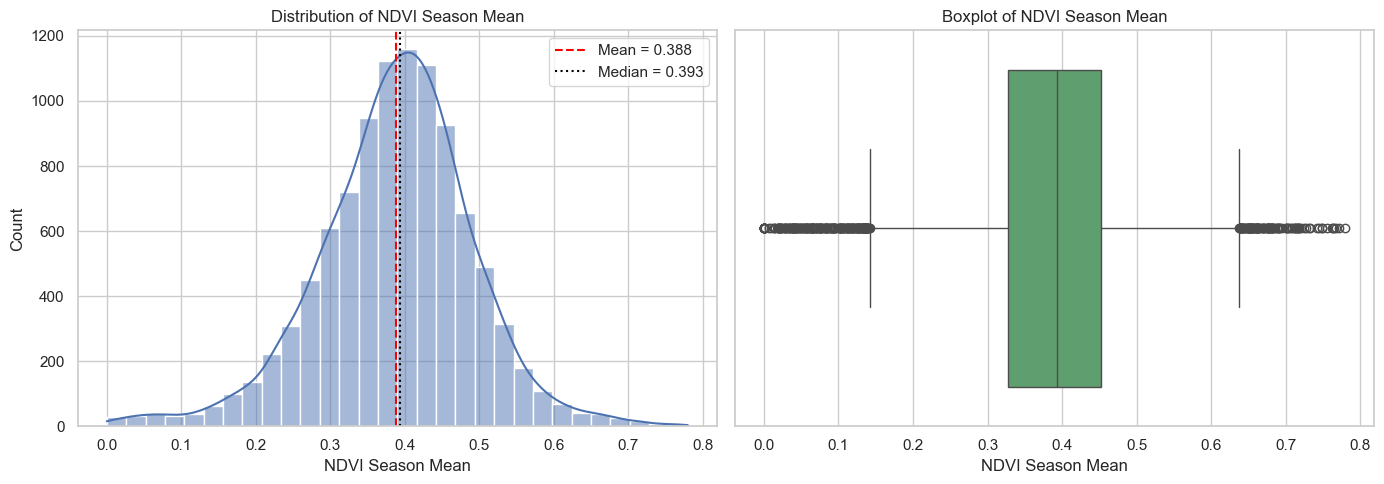

In [7]:
display(df_eda[target].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).to_frame())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df_eda[target], bins=30, kde=True, ax=axes[0], color="#4C72B0")
axes[0].axvline(df_eda[target].mean(), color="red", linestyle="--", label=f"Mean = {df_eda[target].mean():.3f}")
axes[0].axvline(df_eda[target].median(), color="black", linestyle=":", label=f"Median = {df_eda[target].median():.3f}")
axes[0].set_title("Distribution of NDVI")
axes[0].set_xlabel("NDVI")
axes[0].legend()

sns.boxplot(x=df_eda[target], ax=axes[1], color="#55A868")
axes[1].set_title("Boxplot of NDVI")
axes[1].set_xlabel("NDVI")

plt.tight_layout()
plt.show()

**Nhận xét:**

NDVI trung bình khoảng 0.39 và trung vị cũng xấp xỉ 0.39, cho thấy phân phối không bị lệch quá mạnh. Phần lớn quan sát nằm trong khoảng 0.33 đến 0.45. Vẫn có một số giá trị rất thấp, bao gồm một số dòng NDVI bằng 0, chủ yếu cần được kiểm tra thêm theo khu vực/mùa vụ thay vì tự động xem là lỗi.

## 4. NDVI theo mùa vụ

Mùa vụ là biến quan trọng vì điều kiện khí hậu, lượng mưa, nhiệt độ và loại cây trồng có thể thay đổi đáng kể giữa các mùa.

,count,mean,median,std,min,max
Season,,,,,,
Rabi,2780,0.4362,0.4286,0.0826,0.1862,0.7796
Kharif 2,3892,0.4176,0.4200,0.0940,0.0071,0.7020
Kharif 1,3326,0.3121,0.3159,0.0875,0.0000,0.5273


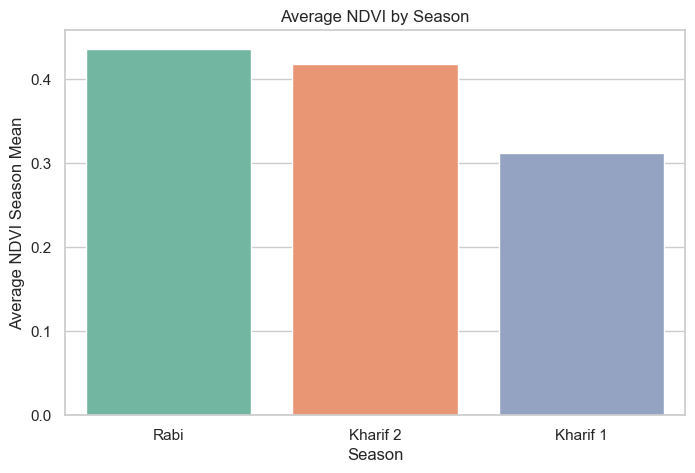

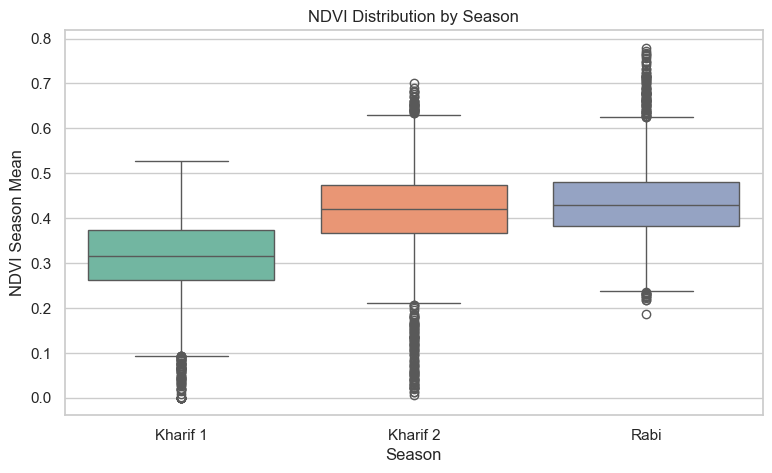

In [8]:
season_summary = (
    df_eda.groupby("Season")[target]
    .agg(count="count", mean="mean", median="median", std="std", min="min", max="max")
    .sort_values("mean", ascending=False)
)
display(season_summary)

plt.figure(figsize=(8, 5))
sns.barplot(data=season_summary.reset_index(), x="Season", y="mean", hue="Season", dodge=False, legend=False)
plt.title("Average NDVI by Season")
plt.xlabel("Season")
plt.ylabel("Average NDVI")
plt.show()

plt.figure(figsize=(9, 5))
sns.boxplot(data=df_eda, x="Season", y=target, hue="Season", dodge=False, legend=False)
plt.title("NDVI Distribution by Season")
plt.xlabel("Season")
plt.ylabel("NDVI")
plt.show()

**Nhận xét:**

NDVI trung bình cao nhất ở mùa `Rabi`, tiếp theo là `Kharif 2`, và thấp nhất ở `Kharif 1`. Điều này cho thấy sức khỏe cây trồng trong dữ liệu có sự khác biệt rõ theo mùa vụ. `Kharif 1` cũng gắn với điều kiện nhiệt độ cao và số ngày stress nhiệt lớn hơn, nên đây là nhóm cần chú ý khi phân tích rủi ro sinh trưởng.

## 5. NDVI theo cây trồng

Phần này so sánh NDVI trung bình giữa các loại cây. Cần lưu ý rằng NDVI khác nhau không chỉ do bản thân cây trồng, mà còn do mùa vụ, khu vực, điều kiện đất và thời tiết đi kèm.

,count,mean,median,std
Crop_Name,,,,
Banana,139,0.5112,0.5060,0.0717
Boro,139,0.4928,0.4829,0.0747
Palmyra Palm,139,0.4922,0.4829,0.0707
Lemon,139,0.4899,0.4747,0.0820
Betelnut,139,0.4884,0.4891,0.0792
Black Berry,139,0.4783,0.4758,0.0860
Green Palmyra,139,0.4711,0.4742,0.0855
Boroi,139,0.4708,0.4694,0.0776
Jamrul,139,0.4707,0.4726,0.0888


,count,mean,median,std
Crop_Name,,,,
Jambura,139,0.3308,0.3439,0.0865
Wood Apple,139,0.3302,0.3415,0.0731
Dalim,138,0.3260,0.3280,0.0883
Date Palm,138,0.3210,0.3262,0.0753
Ripe Papaya,139,0.3166,0.3181,0.0818
Green Papaya,138,0.3109,0.3128,0.0754
Aus,138,0.3096,0.3118,0.0858
Maize 1,139,0.3003,0.3015,0.0749
Lady’s Finger,139,0.2801,0.2873,0.0903


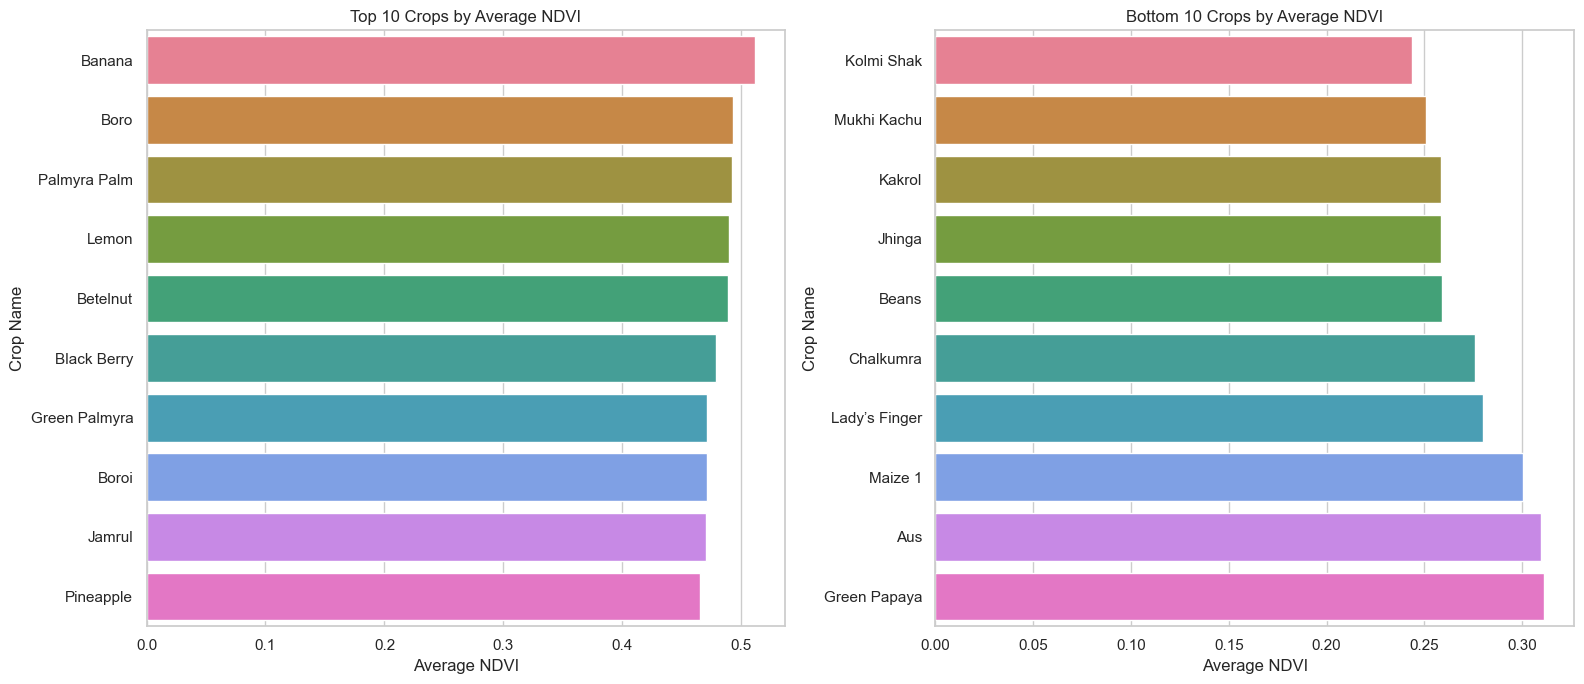

In [9]:
crop_summary = (
    df_eda.groupby("Crop_Name")[target]
    .agg(count="count", mean="mean", median="median", std="std")
    .sort_values("mean", ascending=False)
)

display(crop_summary.head(15))
display(crop_summary.tail(15))

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

top_crops = crop_summary.head(10).reset_index()
sns.barplot(data=top_crops, x="mean", y="Crop_Name", ax=axes[0], hue="Crop_Name", dodge=False, legend=False)
axes[0].set_title("Top 10 Crops by Average NDVI")
axes[0].set_xlabel("Average NDVI")
axes[0].set_ylabel("Crop Name")

bottom_crops = crop_summary.tail(10).sort_values("mean", ascending=True).reset_index()
sns.barplot(data=bottom_crops, x="mean", y="Crop_Name", ax=axes[1], hue="Crop_Name", dodge=False, legend=False)
axes[1].set_title("Bottom 10 Crops by Average NDVI")
axes[1].set_xlabel("Average NDVI")
axes[1].set_ylabel("Crop Name")

plt.tight_layout()
plt.show()

**Nhận xét:**

Nhóm cây có NDVI trung bình cao nhất gồm `Banana`, `Boro`, `Palmyra Palm`, `Lemon`, `Betelnut`, `Black Berry`, `Green Palmyra`, `Boroi`, `Jamrul` và `Pineapple`. `Banana` là cây có NDVI trung bình cao nhất trong dữ liệu sau khi loại lỗi `#REF!`.

Tuy nhiên, kết luận này chỉ mang tính mô tả. Muốn nói cây nào “khỏe hơn” một cách chắc chắn hơn, cần kiểm soát thêm mùa vụ, district và điều kiện môi trường.

## 6. NDVI theo khu vực

District có thể phản ánh khác biệt về đất, khí hậu, địa hình, canh tác hoặc chất lượng dữ liệu. Vì vậy, cần xem các district có NDVI thấp/cao nổi bật.

,count,mean,median,std
District,,,,
Sunamganj,160,0.1728,0.0713,0.1803
Kishoreganj,147,0.2309,0.1804,0.1203
Bhola,147,0.2560,0.2527,0.0445
Netrokona,173,0.2730,0.2995,0.1120
Sirajganj,162,0.2854,0.2726,0.0727
Kurigram,157,0.3063,0.3167,0.0788
Dhaka,150,0.3218,0.3194,0.0641
Gaibandha,149,0.3235,0.3337,0.0633
Sylhet,149,0.3280,0.3731,0.1340


,count,mean,median,std
District,,,,
Thakurgaon,151,0.4236,0.4308,0.0659
Narail,161,0.4270,0.4285,0.0650
Jashore,155,0.4489,0.4555,0.0684
Magura,160,0.4505,0.4488,0.0462
Bagerhat,158,0.4510,0.4841,0.1047
Chuadanga,151,0.4519,0.4375,0.0692
Pirojpur,135,0.4577,0.4665,0.0704
Jhenaidah,150,0.4582,0.4576,0.0614
Chattogram,154,0.4699,0.4770,0.0689


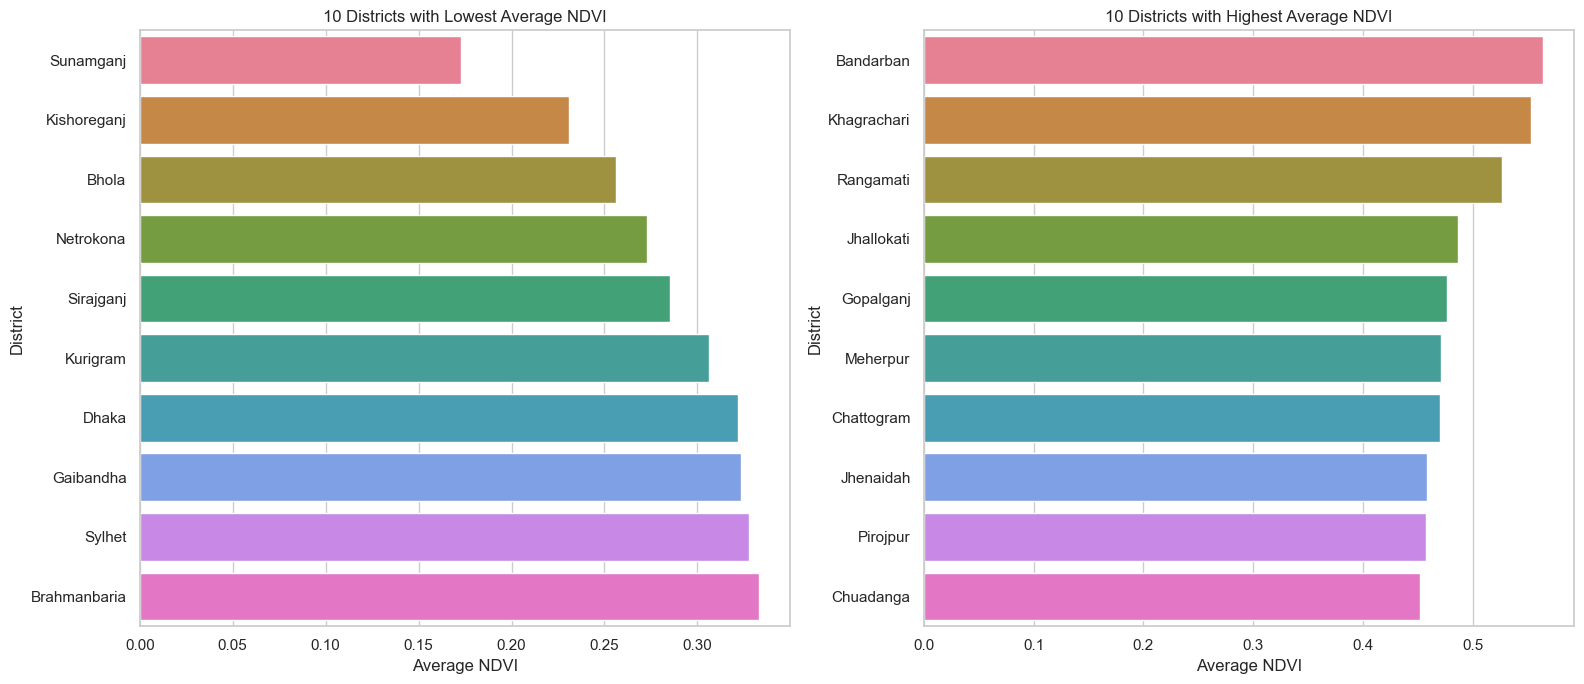

In [10]:
district_summary = (
    df_eda.groupby("District")[target]
    .agg(count="count", mean="mean", median="median", std="std")
    .sort_values("mean")
)

display(district_summary.head(15))
display(district_summary.tail(15))

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

lowest_districts = district_summary.head(10).reset_index()
sns.barplot(data=lowest_districts, x="mean", y="District", ax=axes[0], hue="District", dodge=False, legend=False)
axes[0].set_title("10 Districts with Lowest Average NDVI")
axes[0].set_xlabel("Average NDVI")
axes[0].set_ylabel("District")

highest_districts = district_summary.tail(10).sort_values("mean", ascending=False).reset_index()
sns.barplot(data=highest_districts, x="mean", y="District", ax=axes[1], hue="District", dodge=False, legend=False)
axes[1].set_title("10 Districts with Highest Average NDVI")
axes[1].set_xlabel("Average NDVI")
axes[1].set_ylabel("District")

plt.tight_layout()
plt.show()

**Nhận xét:**

`Sunamganj` là district có NDVI trung bình thấp nhất, thấp hơn đáng kể so với nhiều khu vực khác. Các district như `Kishoreganj`, `Bhola` và `Netrokona` cũng nằm trong nhóm thấp. Đây là những khu vực nên được phân tích thêm theo mùa vụ, lượng mưa, độ mặn và nhiệt độ để hiểu rõ nguyên nhân.

## 7. Tương quan giữa các biến số

Correlation giúp xác định các biến có quan hệ tuyến tính với NDVI. Tuy nhiên, correlation không chứng minh quan hệ nhân quả và có thể bị ảnh hưởng bởi mùa vụ hoặc biến trung gian.

,correlation_with_NDVI
Avg_Salinity_Index,-0.5764
LST_C,-0.3570
Wind_Mean,-0.3359
Temp_Max,-0.3359
Rainfall,-0.3326
Rain_Temp_Ratio,-0.3270
Heat_Stress_Days,-0.3255
Temp_Mean,-0.2960
Soil_Moisture_mm,-0.2903
Wind_Max,-0.1538


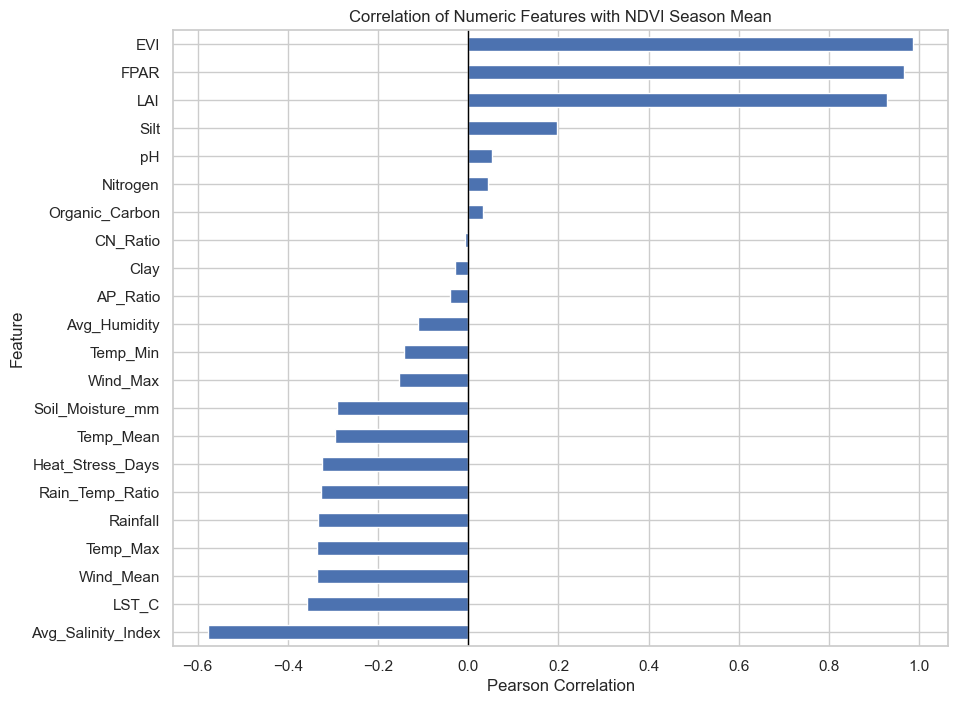

In [11]:
numeric_df = df_eda.select_dtypes(include="number")
corr_matrix = numeric_df.corr()

target_corr = corr_matrix[target].sort_values()
display(target_corr.to_frame("correlation_with_NDVI"))

plt.figure(figsize=(10, 8))
target_corr.drop(target).plot(kind="barh", color="#4C72B0")
plt.title("Correlation of Numeric Features with NDVI")
plt.xlabel("Pearson Correlation")
plt.ylabel("Feature")
plt.axvline(0, color="black", linewidth=1)
plt.show()

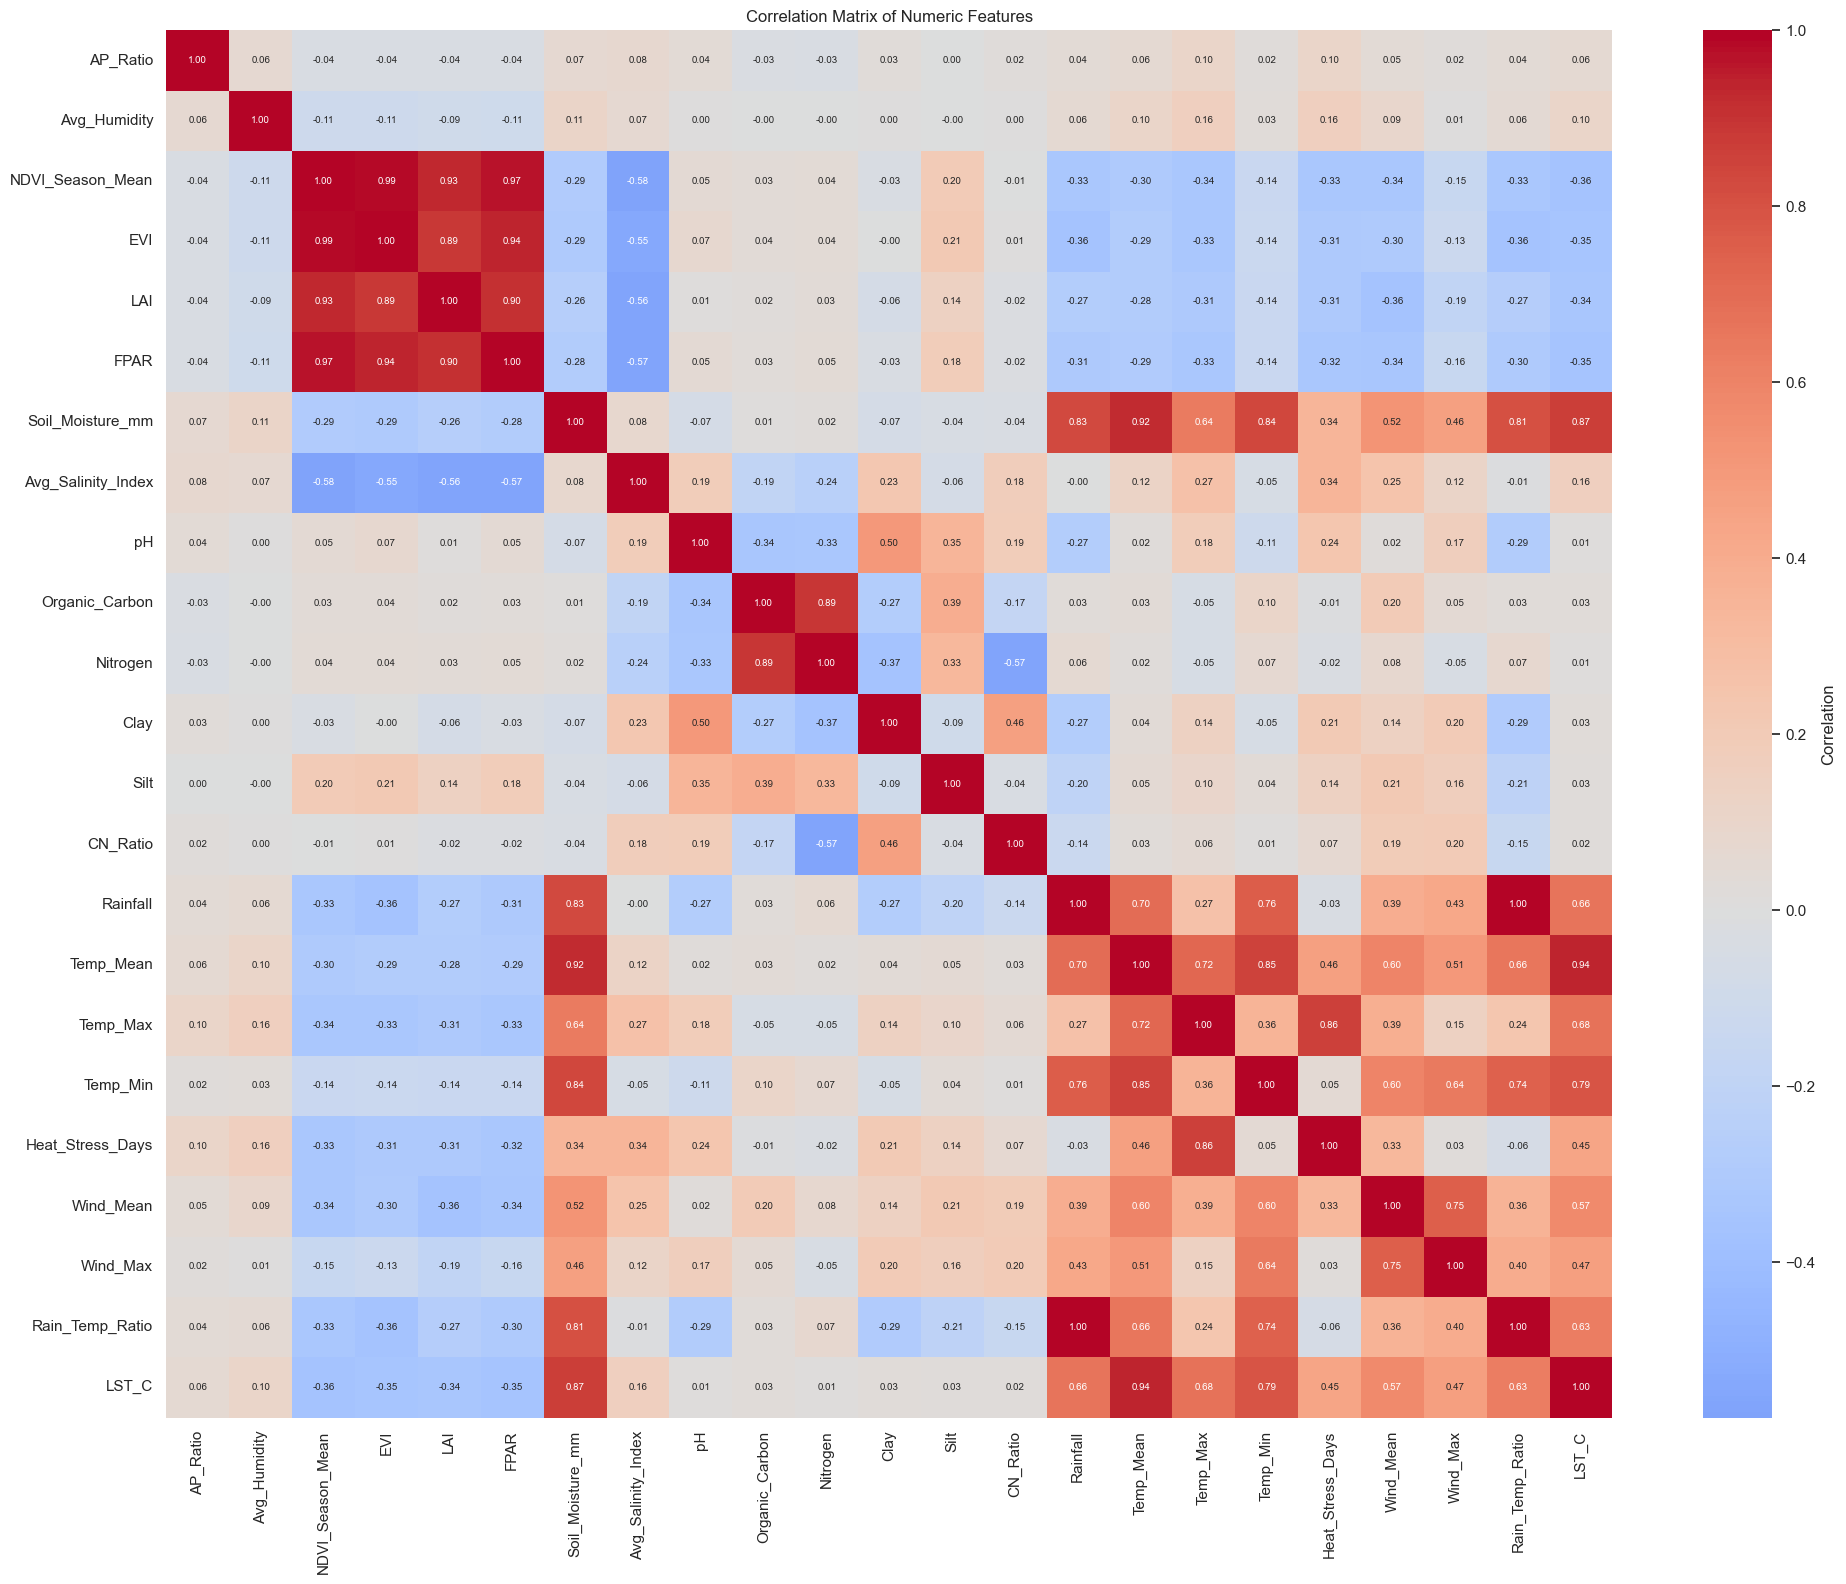

In [12]:
plt.figure(figsize=(20, 16))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 7},
    square=False,
    cbar_kws={"label": "Correlation"}
)
plt.title("Correlation Matrix of Numeric Features")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

**Nhận xét:**

`EVI`, `FPAR` và `LAI` có tương quan dương rất cao với `NDVI`. Điều này hợp lý vì chúng đều là các chỉ số thực vật/che phủ sinh học liên quan chặt chẽ với sức khỏe cây trồng. Nếu mục tiêu sau này là xây dựng mô hình dự đoán NDVI, cần cân nhắc vì các biến này có thể gây multicollinearity hoặc gần với target về mặt thông tin.

Trong các biến môi trường, `Avg_Salinity_Index` có tương quan âm rõ nhất với NDVI, khoảng -0.58 trong dữ liệu hiện tại. Các biến như `LST_C`, `Wind_Mean`, `Temp_Max`, `Rainfall`, `Rain_Temp_Ratio` và `Heat_Stress_Days` cũng có tương quan âm mức vừa. Điều này gợi ý rằng điều kiện độ mặn, nhiệt độ cao, stress nhiệt và một số yếu tố thời tiết bất lợi có thể đi kèm với NDVI thấp hơn.

## 8. Độ mặn và NDVI

Độ mặn là biến có tương quan âm rõ với NDVI, nên cần quan sát trực tiếp bằng scatter plot và phân tách theo mùa vụ.

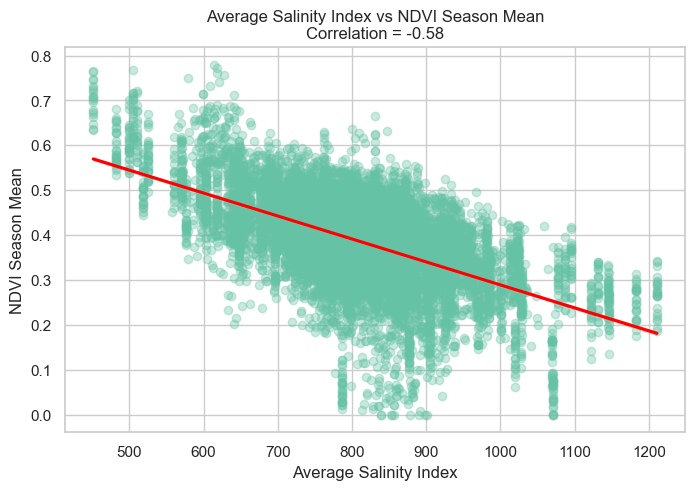

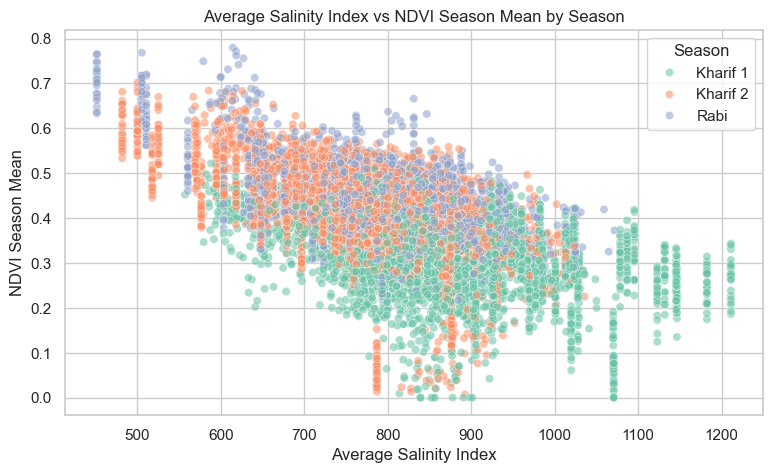

,count,mean_ndvi,mean_salinity,mean_soil_moisture,mean_temp_max,mean_rainfall,mean_heat_stress_days
Season,,,,,,,
Rabi,2780,0.4362,788.2006,10.5379,30.3261,109.0475,0.0000
Kharif 2,3892,0.4176,764.3026,25.7782,34.2378,"1,235.2512",1.2816
Kharif 1,3326,0.3121,873.5459,26.8230,39.6250,"1,089.1702",38.4020


In [13]:
x_col = "Avg_Salinity_Index"
corr_value = df_eda[[x_col, target]].corr().iloc[0, 1]

plt.figure(figsize=(8, 5))
sns.regplot(data=df_eda, x=x_col, y=target, scatter_kws={"alpha": 0.35}, line_kws={"color": "red"})
plt.title(f"Average Salinity Index vs NDVI\nCorrelation = {corr_value:.2f}")
plt.xlabel("Average Salinity Index")
plt.ylabel("NDVI")
plt.show()

plt.figure(figsize=(9, 5))
sns.scatterplot(data=df_eda, x=x_col, y=target, hue="Season", alpha=0.55)
plt.title("Average Salinity Index vs NDVI by Season")
plt.xlabel("Average Salinity Index")
plt.ylabel("NDVI")
plt.legend(title="Season")
plt.show()

season_env_summary = df_eda.groupby("Season").agg(
    count=(target, "count"),
    mean_ndvi=(target, "mean"),
    mean_salinity=("Avg_Salinity_Index", "mean"),
    mean_soil_moisture=("Soil_Moisture_mm", "mean"),
    mean_temp_max=("Temp_Max", "mean"),
    mean_rainfall=("Rainfall", "mean"),
    mean_heat_stress_days=("Heat_Stress_Days", "mean")
).sort_values("mean_ndvi", ascending=False)

display(season_env_summary)

**Nhận xét:**

Độ mặn trung bình có quan hệ âm với NDVI: khi `Avg_Salinity_Index` tăng, NDVI thường giảm. Hệ số tương quan khoảng -0.58, cho thấy quan hệ âm khá rõ nhưng không nên diễn giải là tuyệt đối hay là nguyên nhân duy nhất.

Theo mùa vụ, `Kharif 1` có NDVI thấp hơn và đồng thời có độ mặn, nhiệt độ tối đa và số ngày stress nhiệt cao hơn. Vì vậy, tác động quan sát được có thể là kết hợp của nhiều yếu tố môi trường chứ không chỉ riêng độ mặn.

## 9. Nhiệt độ, stress nhiệt và NDVI

Nhiệt độ cao và số ngày stress nhiệt có thể ảnh hưởng đến sức khỏe cây trồng, đặc biệt trong các mùa nóng.

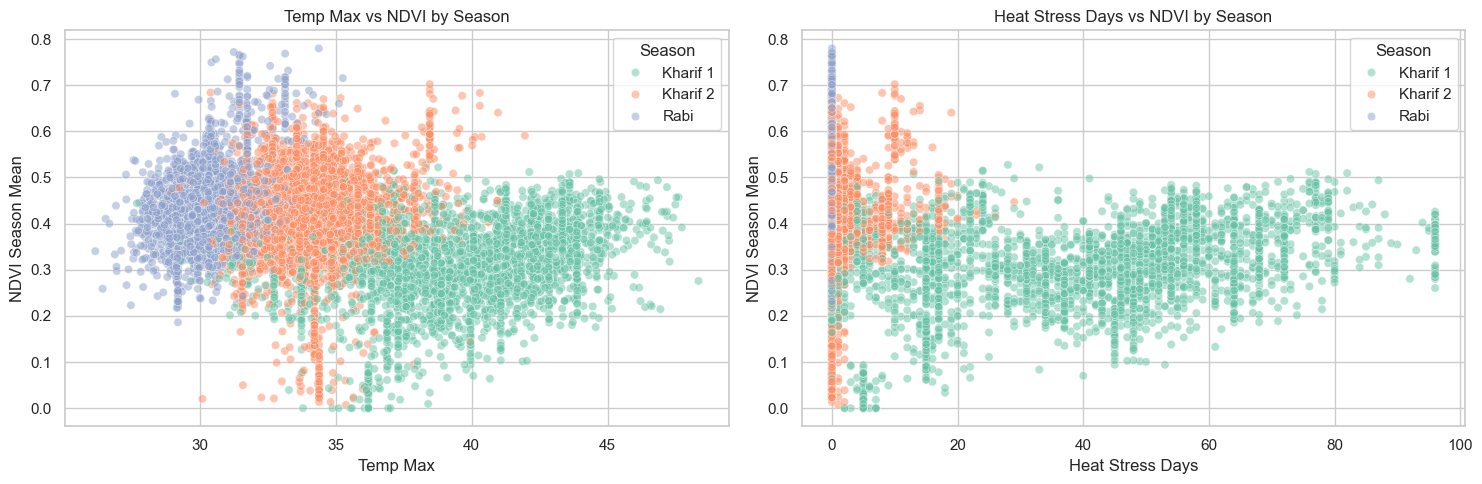

Correlation with NDVI:


,NDVI
LST_C,-0.3570
Temp_Max,-0.3359
Heat_Stress_Days,-0.3255
Temp_Mean,-0.2960
NDVI,1.0000


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.scatterplot(data=df_eda, x="Temp_Max", y=target, hue="Season", alpha=0.5, ax=axes[0])
axes[0].set_title("Temp Max vs NDVI by Season")
axes[0].set_xlabel("Temp Max")
axes[0].set_ylabel("NDVI")

sns.scatterplot(data=df_eda, x="Heat_Stress_Days", y=target, hue="Season", alpha=0.5, ax=axes[1])
axes[1].set_title("Heat Stress Days vs NDVI by Season")
axes[1].set_xlabel("Heat Stress Days")
axes[1].set_ylabel("NDVI")

plt.tight_layout()
plt.show()

print("Correlation with NDVI:")
display(df_eda[[target, "Temp_Max", "Temp_Mean", "LST_C", "Heat_Stress_Days"]].corr()[target].sort_values().to_frame())

**Nhận xét:**

`Temp_Max`, `LST_C` và `Heat_Stress_Days` đều có tương quan âm với NDVI. `Kharif 1` tập trung nhiều hơn ở vùng nhiệt độ cao và số ngày stress nhiệt lớn, đồng thời có NDVI thấp hơn. Điều này củng cố giả thuyết rằng điều kiện nhiệt bất lợi có liên quan đến sức khỏe cây trồng thấp hơn trong dataset.

## 10. Độ ẩm đất, lượng mưa và NDVI

Độ ẩm đất/lượng mưa không phải lúc nào cũng có quan hệ tuyến tính đơn giản với NDVI, vì ảnh hưởng còn phụ thuộc mùa vụ, loại cây, đất và tình trạng ngập úng hoặc stress môi trường khác.

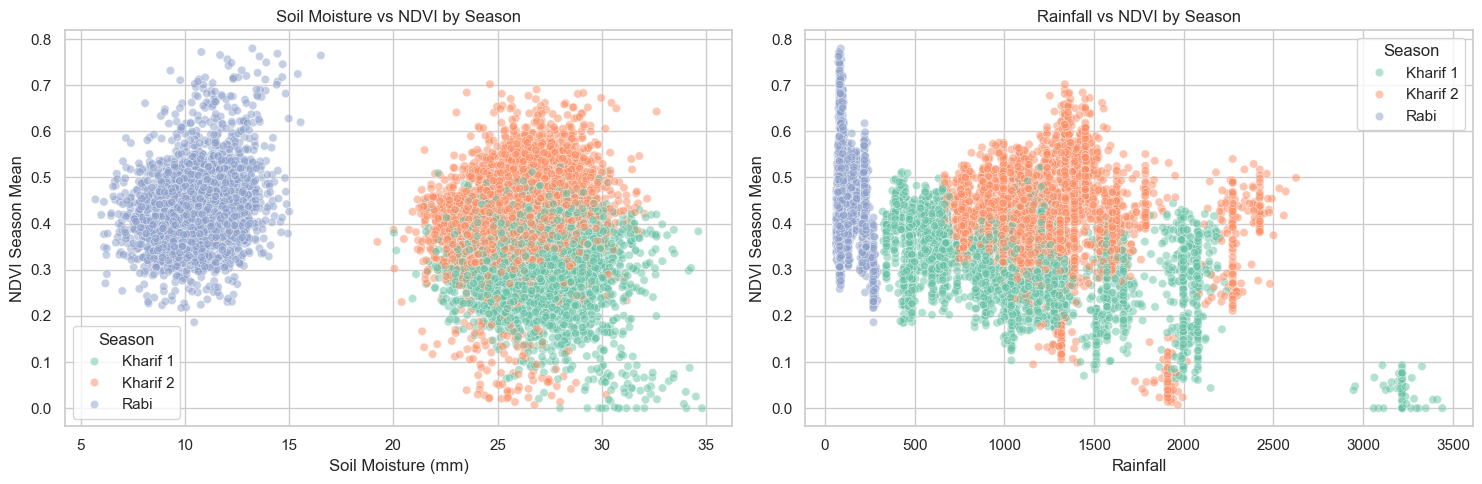

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.scatterplot(data=df_eda, x="Soil_Moisture_mm", y=target, hue="Season", alpha=0.5, ax=axes[0])
axes[0].set_title("Soil Moisture vs NDVI by Season")
axes[0].set_xlabel("Soil Moisture (mm)")
axes[0].set_ylabel("NDVI")

sns.scatterplot(data=df_eda, x="Rainfall", y=target, hue="Season", alpha=0.5, ax=axes[1])
axes[1].set_title("Rainfall vs NDVI by Season")
axes[1].set_xlabel("Rainfall")
axes[1].set_ylabel("NDVI")

plt.tight_layout()
plt.show()

In [16]:
fig = px.scatter(
    df_eda,
    x="Soil_Moisture_mm",
    y=target,
    color="Season",
    hover_data=["Crop_Name", "District", "Rainfall", "Heat_Stress_Days", "Avg_Salinity_Index"],
    title="Interactive Scatter Plot: Soil Moisture vs NDVI"
)
fig.update_layout(
    xaxis_title="Soil Moisture (mm)",
    yaxis_title="NDVI",
    legend_title="Season"
)
fig.show()

**Nhận xét:**

`Soil_Moisture_mm` và `Rainfall` có tương quan âm với NDVI trong dữ liệu tổng thể, nhưng quan hệ này bị chi phối mạnh bởi mùa vụ. `Rabi` có độ ẩm đất và lượng mưa thấp hơn nhưng NDVI trung bình cao hơn; trong khi `Kharif 1` có mưa/ẩm cao hơn nhưng NDVI thấp hơn. Vì vậy, không nên kết luận đơn giản rằng nhiều nước hơn làm NDVI giảm; cần xem xét bối cảnh mùa vụ, nhiệt độ, độ mặn và khả năng ngập úng.

## 11. Outlier của AP_Ratio

`AP_Ratio` có phân phối lệch mạnh và một số giá trị rất lớn. Đây là biến cần kiểm tra kỹ nếu dùng trong phân tích hoặc mô hình hóa.

,AP_Ratio
count,"9,998.0000"
mean,4.6326
std,16.9883
min,0.0000
50%,2.5255
75%,4.3426
90%,8.7560
95%,14.5765
99%,28.7484
max,989.3712


,AP_Ratio,District,Season,Crop_Name,Rainfall,Temp_Mean,NDVI
5614,989.3712,Netrokona,Kharif 1,Jack Fruit,"2,005.8100",27.7371,0.1818
7178,951.2167,Netrokona,Kharif 1,Jack Fruit,"1,997.2200",27.3141,0.1613
8633,291.9018,Jamalpur,Kharif 1,Jack Fruit,"1,300.0900",28.5528,0.2856
3354,286.9471,Kushtia,Kharif 1,Jack Fruit,619.8600,29.5153,0.4374
1010,286.8100,Jamalpur,Kharif 1,Jack Fruit,"1,278.2200",28.1570,0.2583
6979,275.8533,Kushtia,Kharif 1,Jack Fruit,638.5700,29.1759,0.4289
9916,228.2512,Sirajganj,Kharif 1,Jack Fruit,"1,008.2000",27.9027,0.2608
3192,207.9147,Sirajganj,Kharif 1,Jack Fruit,"1,047.5600",27.6917,0.3054
4139,204.1359,Sirajganj,Kharif 1,Jack Fruit,"1,011.4400",28.6632,0.2586
3908,201.7979,Sirajganj,Kharif 1,Jack Fruit,"1,038.7900",28.6633,0.2800


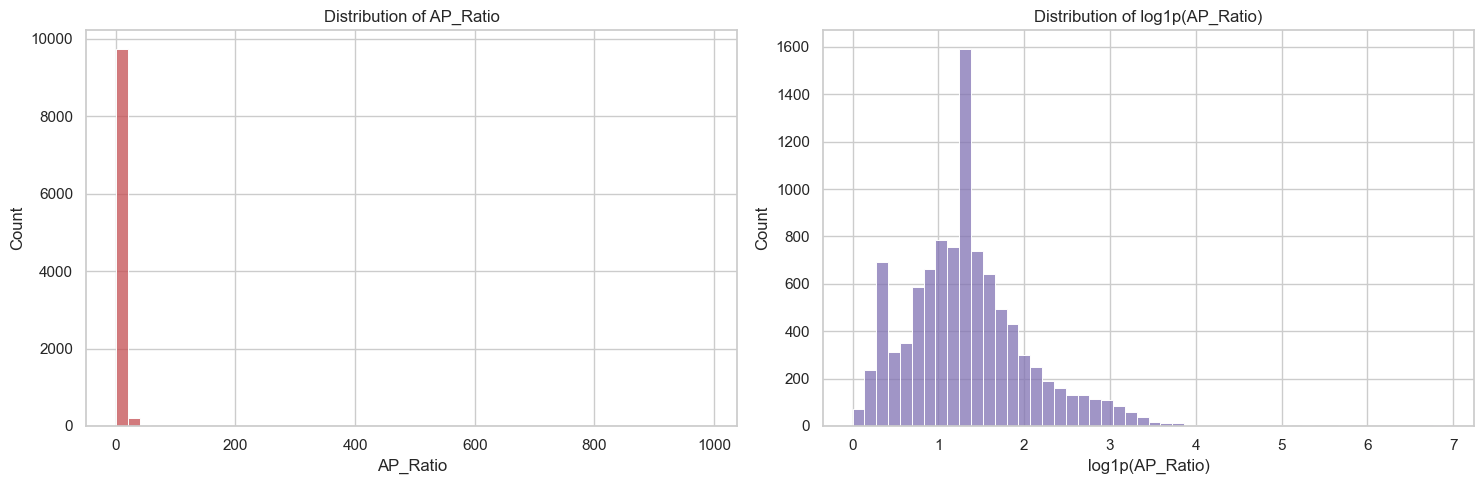

In [17]:
display(df_eda["AP_Ratio"].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]).to_frame())

top_ap = df_eda[["AP_Ratio", "District", "Season", "Crop_Name", "Rainfall", "Temp_Mean", target]].sort_values("AP_Ratio", ascending=False).head(15)
display(top_ap)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(df_eda["AP_Ratio"], bins=50, ax=axes[0], color="#C44E52")
axes[0].set_title("Distribution of AP_Ratio")
axes[0].set_xlabel("AP_Ratio")

sns.histplot(np.log1p(df_eda["AP_Ratio"]), bins=50, ax=axes[1], color="#8172B3")
axes[1].set_title("Distribution of log1p(AP_Ratio)")
axes[1].set_xlabel("log1p(AP_Ratio)")

plt.tight_layout()
plt.show()

**Nhận xét:**

`AP_Ratio` có outlier rất lớn: median chỉ khoảng 2.53 nhưng giá trị lớn nhất gần 989. Các giá trị cao nhất tập trung ở một số dòng `Jack Fruit`. Trước khi dùng biến này cho modeling, nên kiểm tra lại công thức tạo `AP_Ratio`, nguồn dữ liệu gốc hoặc cân nhắc xử lý outlier bằng log transform/winsorization.